# TIE phase retrieval from real brightfield images

This tutorial walks through quantitative phase imaging on **genuine microscopy
data** from the
[JUMP Cell Painting pilot dataset](https://github.com/jump-cellpainting/datasets).
We start from three brightfield images acquired at slightly different focus
positions and recover the **optical phase** — an invisible map of how light is
slowed down as it passes through the cells.

**What you will learn:**
- What the three brightfield planes look like, and why they differ
- How to call `retrieve_phase` with physical parameters taken from metadata
- How to interpret the phase image (units, sign convention, typical values)
- How many iterations are actually needed (convergence benchmark)
- The difference between the 2-image and 3-image pipelines
- How to use `TIESolver` for efficient batch / time-lapse processing

---

## Dataset

| Property | Value |
|---|---|
| Instrument | PerkinElmer Phenix (Andor Zyla sCMOS) |
| Objective | 20× / NA 1.0 |
| Binning | 2 × 2 |
| Pixel size at sample | **597.98 nm** |
| Illumination | NIR broadband, **740 nm** |
| Plate / field | BR00116991 · r01c01f01 |
| Source | JUMP Cell Painting pilot, [cpg0000-jump-pilot](https://registry.opendata.aws/cellpainting-gallery/) |

The three brightfield channels in the Harmony acquisition protocol are:

| File | Channel | z-offset from focus |
|---|---|---|
| `brightfield_under.tiff` | ch7 Brightfield L | **−4 µm** |
| `brightfield_focus.tiff` | ch8 Brightfield   | **0 µm** (in-focus) |
| `brightfield_over.tiff`  | ch6 Brightfield H | **+7 µm** |

The z-spacing is **not** perfectly symmetric (−4 / +7 µm rather than ±5 µm).
For the central-difference TIE formula we use the effective half-span:

$$
\mathrm{d}z = \frac{|z_H - z_L|}{2} = \frac{11\,\mu\text{m}}{2} = 5.5\,\mu\text{m}
$$

## Setup

In [ ]:
from pathlib import Path
import math
import timeit

import numpy as np
import matplotlib.pyplot as plt
import tifffile

from US_TIE_Zhang_et_al_2020_py import (
    retrieve_phase,
    compute_dIdz,
    TIESolver,
    remove_piston,
)

# Physical parameters from the acquisition metadata (Index.idx.xml)
PIXELSIZE  = 5.9798e-7   # m  — ImageResolutionX from XML
WAVELENGTH = 740e-9      # m  — NIR broadband illumination
DZ         = 5.5e-6      # m  — effective half-span of the z-stack
K          = 2 * math.pi / WAVELENGTH

# Data directory (relative to this notebook)
DATA_DIR = Path('../tests/data')

## 1  Load and inspect the raw images

In [ ]:
I_under = tifffile.imread(DATA_DIR / 'brightfield_under.tiff').astype(float)
I_focus = tifffile.imread(DATA_DIR / 'brightfield_focus.tiff').astype(float)
I_over  = tifffile.imread(DATA_DIR / 'brightfield_over.tiff').astype(float)

print(f'Image shape : {I_focus.shape}')
print(f'Pixel size  : {PIXELSIZE*1e9:.1f} nm  →  field of view {I_focus.shape[0]*PIXELSIZE*1e6:.1f} µm')
print()
for name, img in [('Brightfield L  (−4 µm)', I_under),
                  ('Brightfield     (0 µm)', I_focus),
                  ('Brightfield H  (+7 µm)', I_over)]:
    print(f'{name}:  mean={img.mean():.0f}  std={img.std():.0f}  '
          f'[{img.min():.0f}, {img.max():.0f}]')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

titles = [
    'I_under  (Brightfield L, −4 µm)',
    'I_focus  (Brightfield, in-focus)',
    'I_over   (Brightfield H, +7 µm)',
]
images = [I_under, I_focus, I_over]

vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)

for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

fig.colorbar(im, ax=axes, shrink=0.7, label='Intensity (ADU)')
fig.suptitle('Raw brightfield images — JUMP Cell Painting, plate BR00116991',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('Notice: the in-focus image looks the most uniform (featureless).')
print('Defocus introduces diffraction rings that increase contrast.')
print('The TIE turns this contrast difference into a phase map.')

**What you are seeing**: transmitted light through a monolayer of human cells.
The cells are nearly transparent — the brightness differences between the three
planes are small (< 5 % of the mean) but contain all the phase information we
need.

## 2  Recover the phase — three-image pipeline (recommended)

In [ ]:
phase_3 = retrieve_phase(
    images=[I_under, I_focus, I_over],
    dz=DZ,
    pixelsize=PIXELSIZE,
    wavelength=WAVELENGTH,
)
phase_3 = remove_piston(phase_3)

print(f'Phase range: {phase_3.min():.3f} to {phase_3.max():.3f} rad')
print(f'Phase std  : {phase_3.std():.3f} rad')
print()
print('Typical cells produce 0.1 – 1.5 rad of phase at 740 nm illumination.')

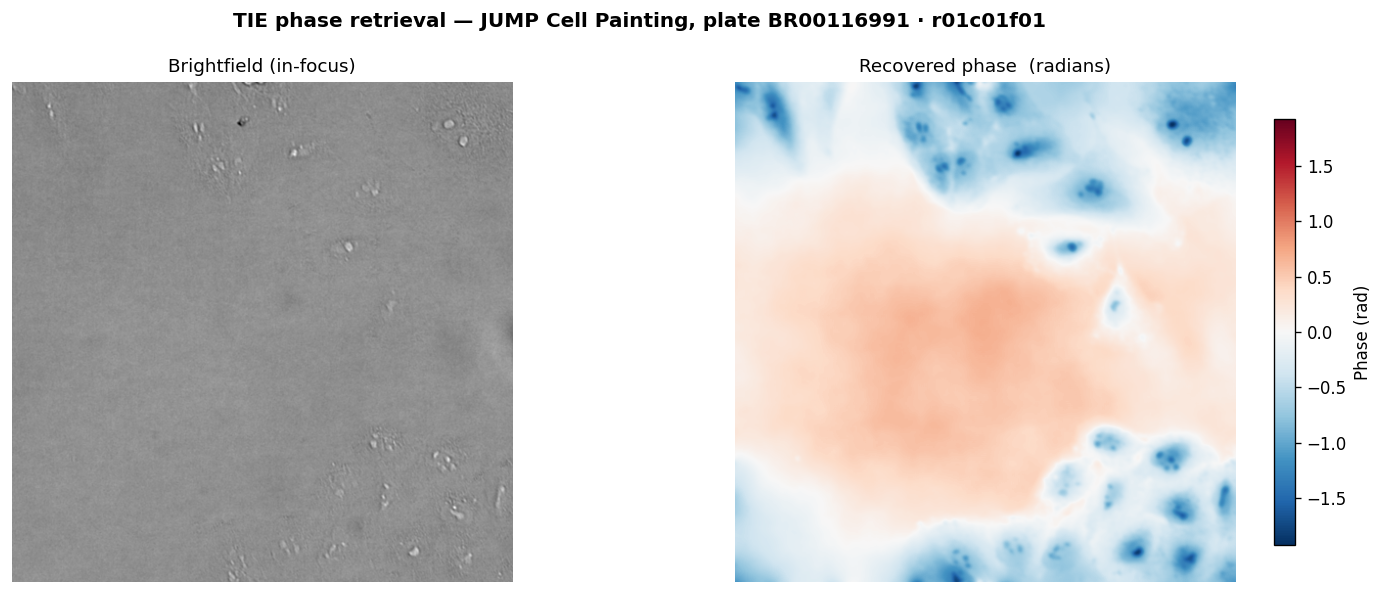

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(I_focus, cmap='gray')
axes[0].set_title('Brightfield (in-focus)', fontsize=11)
axes[0].axis('off')

sym = max(abs(phase_3.min()), abs(phase_3.max()))
im = axes[1].imshow(phase_3, cmap='RdBu_r', vmin=-sym, vmax=sym)
axes[1].set_title('Recovered phase  (radians)', fontsize=11)
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], shrink=0.85, label='Phase (rad)')

fig.suptitle(
    'TIE phase retrieval — JUMP Cell Painting, plate BR00116991 · r01c01f01',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

**Reading the phase map:**
- **Red regions** (positive phase) = light is slowed down = denser or thicker material.
  Cells and their organelles show up red.
- **Blue regions** (negative phase) = lighter than the surrounding medium.
- The **colour scale is in radians**.
  Convert to optical path length (OPL in nm): `OPL = φ × λ / (2π) = φ × 740 / (2π)`

## 3  How many iterations are actually needed?

The US-TIE algorithm is iterative. The default `max_iter=500` is conservative.
Here we time each iteration count and measure RMSE against the 500-iteration
reference to find the practical convergence point.

In [ ]:
# --- convergence benchmark ---
dIdz, I0 = compute_dIdz([I_under, I_focus, I_over], DZ)
solver = TIESolver((512, 512), PIXELSIZE, K)

# Reference: run to 500 iterations
ref = remove_piston(solver.solve(dIdz, I0, max_iter=500)['phase'])

iter_counts = [1, 2, 3, 5, 10, 20, 50, 100, 500]
times_ms    = []
rmses       = []

for n in iter_counts:
    t = timeit.timeit(lambda n=n: solver.solve(dIdz, I0, max_iter=n), number=3) / 3
    p = remove_piston(solver.solve(dIdz, I0, max_iter=n)['phase'])
    rmse = float(np.sqrt(np.mean((p - ref)**2)))
    times_ms.append(t * 1000)
    rmses.append(rmse)
    print(f'  max_iter={n:4d}: {t*1000:7.0f} ms   RMSE={rmse:.2e} rad')

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogx(iter_counts, times_ms, 'o-', color='steelblue')
ax1.set_xlabel('max_iter')
ax1.set_ylabel('Wall time (ms)')
ax1.set_title('Processing time vs iterations')
ax1.grid(True, which='both', alpha=0.3)
ax1.axvline(10, color='orange', linestyle='--', label='recommended (10)')
ax1.legend()

ax2.semilogy(iter_counts, rmses, 's-', color='firebrick')
ax2.set_xlabel('max_iter')
ax2.set_ylabel('RMSE vs 500-iter reference (rad)')
ax2.set_title('Convergence: error vs iterations')
ax2.grid(True, which='both', alpha=0.3)
ax2.axvline(10, color='orange', linestyle='--', label='recommended (10)')
ax2.legend()

fig.suptitle('US-TIE convergence — 512×512 JUMP Cell Painting image',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
i10 = iter_counts.index(10)
i500 = iter_counts.index(500)
print(f'max_iter=10 : {times_ms[i10]:.0f} ms,  RMSE = {rmses[i10]:.2e} rad')
print(f'max_iter=500: {times_ms[i500]:.0f} ms,  RMSE = 0 (reference)')
print(f'Speed-up from max_iter=10 vs 500: {times_ms[i500]/times_ms[i10]:.0f}×')
print()
print('Recommendation: max_iter=10 for interactive / exploratory use,')
print('                max_iter=50 for publication-quality results.')

## 4  Two-image pipeline (forward difference)

In [ ]:
# Use the actual z-step between I_focus (z=0) and I_over (z=+7 µm).
DZ_OVER = 7e-6

phase_2 = retrieve_phase(
    images=[I_focus, I_over],
    dz=DZ_OVER,
    pixelsize=PIXELSIZE,
    wavelength=WAVELENGTH,
    max_iter=50,
)
phase_2 = remove_piston(phase_2)

corr = np.corrcoef(phase_2.ravel(), phase_3.ravel())[0, 1]
print(f'Correlation between 2- and 3-image phases: {corr:.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sym = max(abs(phase_3).max(), abs(phase_2).max())

im0 = axes[0].imshow(phase_3, cmap='RdBu_r', vmin=-sym, vmax=sym)
axes[0].set_title('3-image TIE  (central difference, dz = 5.5 µm)', fontsize=10)
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], shrink=0.85, label='Phase (rad)')

im1 = axes[1].imshow(phase_2, cmap='RdBu_r', vmin=-sym, vmax=sym)
axes[1].set_title('2-image TIE  (forward difference, dz = 7 µm)', fontsize=10)
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], shrink=0.85, label='Phase (rad)')

fig.suptitle('2-image vs 3-image phase retrieval', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The 3-image central difference cancels first-order defocus artefacts,
which is why it is recommended when all three planes are available.

## 5  Choosing the Poisson solver backend

In [ ]:
phase_fft = remove_piston(retrieve_phase(
    [I_under, I_focus, I_over], DZ, PIXELSIZE, WAVELENGTH,
    solver='fft', max_iter=50,
))
phase_dct = remove_piston(retrieve_phase(
    [I_under, I_focus, I_over], DZ, PIXELSIZE, WAVELENGTH,
    solver='dct', max_iter=50,
))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sym = max(abs(phase_fft).max(), abs(phase_dct).max())

im0 = axes[0].imshow(phase_fft, cmap='RdBu_r', vmin=-sym, vmax=sym)
axes[0].set_title('FFT backend  (periodic BC)', fontsize=10)
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], shrink=0.85, label='Phase (rad)')

im1 = axes[1].imshow(phase_dct, cmap='RdBu_r', vmin=-sym, vmax=sym)
axes[1].set_title('DCT backend  (Neumann BC)', fontsize=10)
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], shrink=0.85, label='Phase (rad)')

fig.suptitle('Effect of Poisson solver boundary conditions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6  Efficient batch processing with TIESolver

In [ ]:
# For time-lapse or multi-field experiments, construct the solver once.
# It precomputes frequency grids and filter kernels and reuses them.
solver = TIESolver(
    shape=(512, 512),
    pixelsize=PIXELSIZE,
    k=K,
    backend='fft',
)

dIdz, I0 = compute_dIdz([I_under, I_focus, I_over], dz=DZ)
result = solver.solve(dIdz, I0, max_iter=50)

print(f'Converged in {result["iterations"]} iterations')

# Simulate a time-lapse of 10 frames
rng = np.random.default_rng(42)
frames = []
for _ in range(10):
    noise = rng.normal(scale=50, size=(512, 512))
    d, i0 = compute_dIdz(
        [I_under + noise, I_focus + noise, I_over + noise], dz=DZ
    )
    frames.append((d, i0))

phases = [remove_piston(solver.solve(d, i0, max_iter=50)['phase'])
          for d, i0 in frames]
print(f'Processed {len(phases)} frames')
print(f'Mean phase std across frames: {np.mean([p.std() for p in phases]):.3f} rad')

## 7  Phase → optical path length and dry mass

In [ ]:
opl_nm = phase_3 * WAVELENGTH * 1e9 / (2 * np.pi)
print(f'OPL range: {opl_nm.min():.1f} to {opl_nm.max():.1f} nm')
print()

pixel_area_um2 = (PIXELSIZE * 1e6) ** 2
dn_dc = 0.185  # mL/g = µm³/pg  (Barer 1952 specific refractive increment for protein)
dm_per_pixel_pg = (opl_nm * 1e-3) * pixel_area_um2 / dn_dc
print(f'Pixel area: {pixel_area_um2:.4f} µm²')
print(f'Dry mass per pixel (mean over positive values): '
      f'{dm_per_pixel_pg[dm_per_pixel_pg > 0].mean():.4f} pg')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sym = max(abs(phase_3.min()), abs(phase_3.max()))
im0 = axes[0].imshow(phase_3, cmap='RdBu_r', vmin=-sym, vmax=sym)
axes[0].set_title('Phase  (radians)', fontsize=11)
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], shrink=0.85, label='φ (rad)')

sym_opl = max(abs(opl_nm.min()), abs(opl_nm.max()))
im1 = axes[1].imshow(opl_nm, cmap='RdBu_r', vmin=-sym_opl, vmax=sym_opl)
axes[1].set_title('Optical path length  (nm)', fontsize=11)
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], shrink=0.85, label='OPL (nm)')

fig.suptitle('Phase and optical path length — JUMP Cell Painting',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

```python
from US_TIE_Zhang_et_al_2020_py import retrieve_phase, remove_piston
import tifffile

I_under = tifffile.imread('brightfield_under.tiff').astype(float)
I_focus = tifffile.imread('brightfield_focus.tiff').astype(float)
I_over  = tifffile.imread('brightfield_over.tiff').astype(float)

phase = retrieve_phase(
    images=[I_under, I_focus, I_over],
    dz=5.5e-6,         # effective half-span of the z-stack  (metres)
    pixelsize=5.98e-7, # pixel size at sample               (metres)
    wavelength=740e-9, # illumination wavelength            (metres)
    max_iter=50,       # 10-50 is sufficient for most data
)
phase = remove_piston(phase)
```

- `phase` is a 2-D float array in **radians**.
- The algorithm converges in ~5–10 iterations on typical data; `max_iter=50` is a safe default.
- `max_iter=10` (~150 ms on a 512×512 image) is adequate for interactive exploration.
- Positive values = specimen is optically denser than the medium.
- Convert to OPL: `opl_nm = phase * wavelength_nm / (2π)`.
- The `TIESolver` class reuses precomputed grids for batch / time-lapse work.

---

## Reference

> Zheng, G., Horstmeyer, R., & Yang, C. (2020).
> On a universal solution to the transport-of-intensity equation.
> *Optics Letters*, 45(7), 1607–1610.
> [arXiv:1912.07371](https://arxiv.org/abs/1912.07371)

> JUMP Cell Painting Pilot:
> Chandrasekaran, S. N. et al. (2023). JUMP Cell Painting dataset: morphological impact
> of 136,000 chemical and genetic perturbations. *bioRxiv*.
> [DOI: 10.1101/2023.03.23.534023](https://doi.org/10.1101/2023.03.23.534023)